In [5]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Gender          690 non-null    object 
 1   Age             690 non-null    object 
 2   Debt            690 non-null    float64
 3   Married         690 non-null    object 
 4   BankCustomer    690 non-null    object 
 5   EducationLevel  690 non-null    object 
 6   Ethnicity       690 non-null    object 
 7   YearsEmployed   690 non-null    float64
 8   PriorDefault    690 non-null    object 
 9   Employed        690 non-null    object 
 10  CreditScore     690 non-null    int64  
 11  DriversLicense  690 non-null    object 
 12  Citizen         690 non-null    object 
 13  ZipCode         690 non-null    object 
 14  Income          690 non-null    int64  
 15  Approved        690 non-null    object 
dtypes: float64(2), int64(2), object(12)
memory usage: 86.4+ KB


,Debt,YearsEmployed,CreditScore,Income
count,690.000000,690.000000,690.00000,690.000000
mean,4.758725,2.223406,2.40000,1017.385507
std,4.978163,3.346513,4.86294,5210.102598
min,0.000000,0.000000,0.00000,0.000000
25%,1.000000,0.165000,0.00000,0.000000
50%,2.750000,1.000000,0.00000,5.000000
75%,7.207500,2.625000,3.00000,395.500000
max,28.000000,28.500000,67.00000,100000.000000


In [6]:
df.isnull().sum()

,0
Gender,0
Age,0
Debt,0
Married,0
BankCustomer,0
EducationLevel,0
Ethnicity,0
YearsEmployed,0
PriorDefault,0
Employed,0


In [7]:
df.replace("?", pd.NA, inplace=True)
df.isnull().sum()

,0
Gender,12
Age,12
Debt,0
Married,6
BankCustomer,6
EducationLevel,9
Ethnicity,9
YearsEmployed,0
PriorDefault,0
Employed,0


In [8]:
df = df.fillna(method='ffill')

/tmp/ipykernel_8039/569672361.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')


In [9]:
df["Age"] = pd.to_numeric(df["Age"])
df["Debt"] = pd.to_numeric(df["Debt"])
df["YearsEmployed"] = pd.to_numeric(df["YearsEmployed"])
df["CreditScore"] = pd.to_numeric(df["CreditScore"])
df["Income"] = pd.to_numeric(df["Income"])

In [10]:
df["Approved"] = df["Approved"].map({"+":1, "-":0})

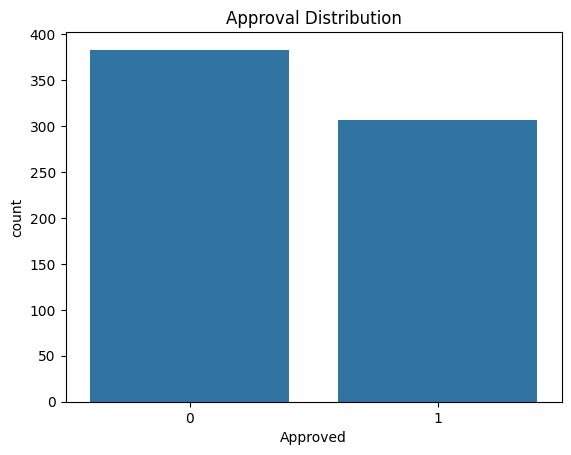

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Approved', data=df)
plt.title("Approval Distribution")
plt.show()

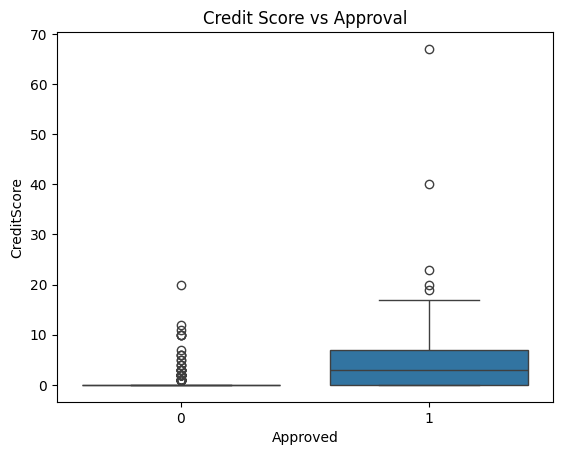

In [12]:
sns.boxplot(x='Approved', y='CreditScore', data=df)
plt.title("Credit Score vs Approval")
plt.show()

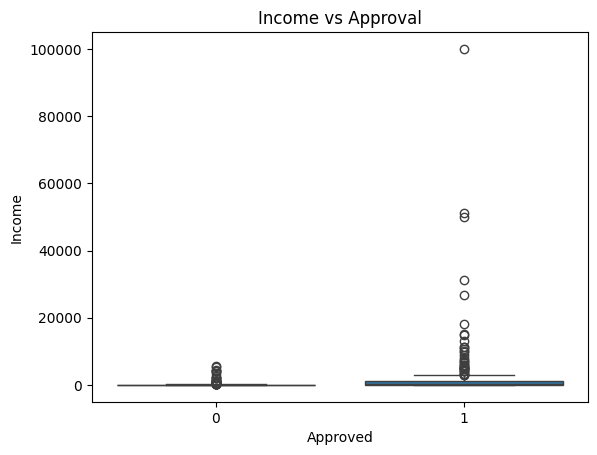

In [13]:
sns.boxplot(x='Approved', y='Income', data=df)
plt.title("Income vs Approval")
plt.show()

In [16]:
df_encoded = df.copy()

for col in df_encoded.columns:
    if df_encoded[col].dtype == 'object':
        df_encoded[col] = df_encoded[col].astype('category').cat.codes

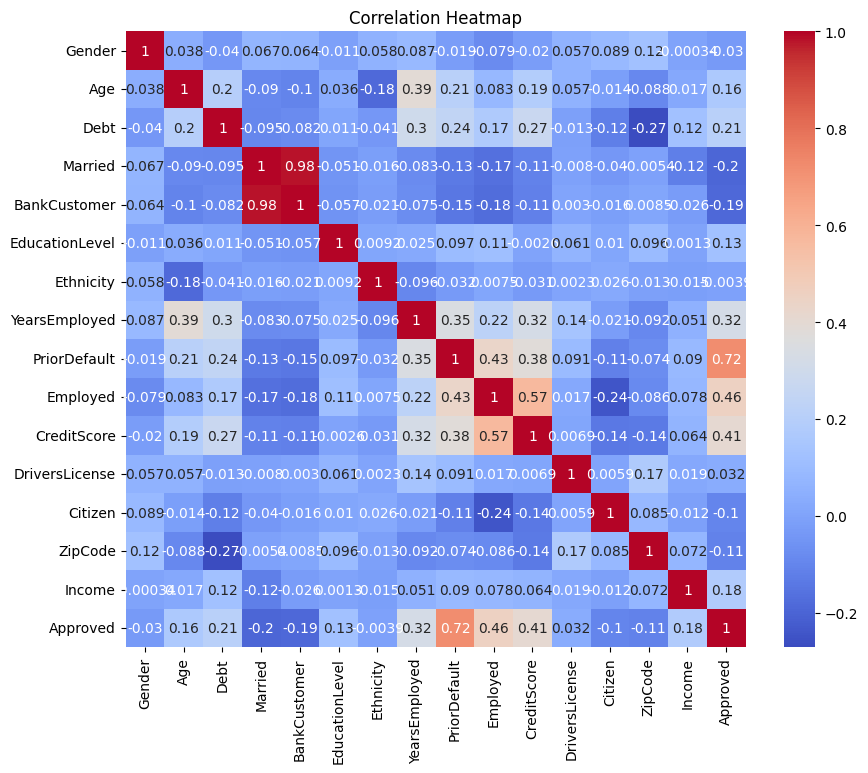

In [17]:
plt.figure(figsize=(10,8))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [15]:
print("Key Insights:")
print("1. Credit Score is a major factor in approval")
print("2. Prior Default strongly affects rejection")
print("3. Higher Income improves approval chances")
print("4. Employment status also impacts decisions")

Key Insights:
1. Credit Score is a major factor in approval
2. Prior Default strongly affects rejection
3. Higher Income improves approval chances
4. Employment status also impacts decisions
